This notebook provides demo code that runs VGGT, introduced in [“VGGT: Visual Geometry-Grounded Transformer” [Wand et al., 2025]](https://github.com/facebookresearch/vggt), and visualizes its results with Rerun.io.

The inference code is adapted from [vggt](https://github.com/facebookresearch/vggt), and the visualization code draws on [vggt-pytorch-inference](https://github.com/ibaiGorordo/vggt-pytorch-inference).

# Install

When using the rerun-sdk in a Kaggle Notebook, you need to restart the notebook after running `pip install`.  
Click the **"︙ (More settings)"** button in the top-right corner and select **"Restart & Clear Cell Outputs"**.

In [ ]:
! uv pip install --system jaxtyping rerun-sdk[notebook]
! uv pip install --system https://github.com/facebookresearch/vggt.git

# Inference

In [ ]:
from dataclasses import dataclass

import torch
from vggt.models.vggt import VGGT
from vggt.utils.geometry import unproject_depth_map_to_point_map
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri


@dataclass
class VGGTResult:
    inputs: torch.Tensor  # [num_images, 3, H, W]
    width: int
    height: int
    extrinsic: torch.Tensor  # [num_images, 3, 4]
    intrinsic: torch.Tensor  # [num_images, 3, 3]
    depth_map: torch.Tensor  # [num_images, H, W, 1]
    depth_conf: torch.Tensor  # [num_images, H, W]
    point_map: torch.Tensor  # [num_images, H, W, 3]
    point_conf: torch.Tensor  # [num_images, H, W]
    point_map_by_unprojection: torch.Tensor  # [num_images, H, W, 3]

    @property
    def images(self) -> torch.Tensor:
        """Convert the inputs to images for visualization.

        Returns:
            torch.Tensor: The images in uint8 format. [num_images, H, W, 3].
        """
        return (self.inputs.permute(0, 2, 3, 1) * 255).clamp(0, 255).to(torch.uint8)


class VGGTRunner:
    """VGGT Runner

    Attributes:
        model_path (str): The path to the VGGT model.
        dtype (torch.dtype | None): The dtype of the model.
        device (torch.device | str | None): The device of the model.
    """

    def __init__(
        self,
        model_path: str = "facebook/VGGT-1B",
        dtype: torch.dtype | None = None,
        device: torch.device | str | None = None,
    ):
        """Initialize the VGGT Runner.

        Args:
            model_path (str): The path to the VGGT model.
            dtype (torch.dtype | None, optional): The dtype for autocasting. Defaults to None.
            device (torch.device | str | None, optional): The device of the model. Defaults to None.
        """
        self.dtype = dtype if dtype is not None else torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16
        self.device = torch.device(device) if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = VGGT.from_pretrained(model_path).eval().to(self.device)

    def __call__(self, image_paths: list[str]) -> VGGTResult:
        """Inference the VGGT model.

        Args:
            image_paths (list[str]): The paths to the images.

        Returns:
            VGGTResult: The result of the inference.
        """
        inputs = load_and_preprocess_images(image_paths).to(self.device).unsqueeze(0)
        with torch.inference_mode():
            with torch.amp.autocast(str(self.device), dtype=self.dtype):
                aggregated_tokens_list, ps_idx = self.model.aggregator(inputs)
            pose_enc = self.model.camera_head(aggregated_tokens_list)[-1]
            extrinsic, intrinsic = pose_encoding_to_extri_intri(pose_enc, inputs.shape[-2:])
            depth_map, depth_conf = self.model.depth_head(aggregated_tokens_list, inputs, ps_idx)
            point_map, point_conf = self.model.point_head(aggregated_tokens_list, inputs, ps_idx)
            point_map_by_unprojection = unproject_depth_map_to_point_map(depth_map.squeeze(0), extrinsic.squeeze(0), intrinsic.squeeze(0))
        return VGGTResult(
            inputs=inputs.cpu().squeeze(0),
            width=inputs.shape[3],
            height=inputs.shape[2],
            extrinsic=extrinsic.cpu().squeeze(0),
            intrinsic=intrinsic.cpu().squeeze(0),
            depth_map=depth_map.cpu().squeeze(0),
            depth_conf=depth_conf.cpu().squeeze(0),
            point_map=point_map.cpu().squeeze(0),
            point_conf=point_conf.cpu().squeeze(0),
            point_map_by_unprojection=torch.from_numpy(point_map_by_unprojection),
        )


In [ ]:
from glob import glob

vggt = VGGTRunner(device="cuda")

image_paths = sorted(glob("/kaggle/input/image-matching-challenge-2025/train/ETs/et_*.png"))
result = vggt(image_paths)

# Visualization


I'll visualize this result with Rerun.io.  
The code below outputs an `.rrd file` and, drag-and-drop that file onto [https://rerun.io/viewer](https://rerun.io/viewer) to view it.  

If you’re running locally, you can simply call `rr.notebook_show()`.  
(Running this command in a Kaggle Notebook threw an error for me. If anyone has a fix, I’d really appreciate a comment!)


In [ ]:
import numpy as np
import rerun as rr
import rerun.blueprint as rrb
from tqdm import tqdm


def draw_pose(transform: np.ndarray, name: str, static: bool = False) -> None:
    rr.log(
        name,
        rr.Arrows3D(
            origins=[0, 0, 0],
            vectors=[[0.03, 0, 0], [0, 0.03, 0], [0, 0, 0.03]],
            colors=[[255, 0, 0], [0, 255, 0], [0, 0, 255]],
            radii=[0.001, 0.001, 0.001],
        ),
        static=static,
    )

    rr.log(
        name,
        rr.Transform3D(
            translation=transform[:3, 3],
            mat3x3=transform[:3, :3],
        ),
        static=static,
    )


rr.init("vggt_inference")
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Horizontal(
            rrb.Spatial3DView(origin="body/pose", contents="body/**"),
            rrb.Vertical(
                rrb.Spatial2DView(origin="body/cam/image"),
                rrb.Spatial2DView(origin="body/cam/depth_map"),
            ),
        )
    )
)

for i in tqdm(range(len(image_paths))):
    rr.set_time_sequence("frame", i)
    world2cam = np.eye(4)
    world2cam[:3, :4] = result.extrinsic[i]
    cam2world = np.linalg.inv(world2cam)
    rr.log(
        "body/cam",
        rr.Pinhole(
            image_from_camera=result.intrinsic[i],
            width=result.width,
            height=result.height,
            image_plane_distance=0.02,
        ),
    )
    rr.log(
        "body/cam",
        rr.Transform3D(
            translation=cam2world[:3, 3],
            mat3x3=cam2world[:3, :3],
        ),
    )
    draw_pose(cam2world, f"body/pose{i}", static=True)
    draw_pose(cam2world, "body/pose")

    # Filter points based on confidence threshold
    conf = result.depth_conf[i]
    conf_thres = np.percentile(conf, 90)
    keep_mask = conf > conf_thres
    depth_maps = result.depth_map[i]
    depth_maps[~keep_mask] = 0

    points = result.point_map_by_unprojection[i].reshape(-1, 3)
    keep_mask = keep_mask.reshape(-1)
    colors = result.images[i].reshape(-1, 3)

    points = points[keep_mask]
    colors = colors[keep_mask]

    rr.log(f"body/points{i}", rr.Points3D(points, colors=colors, radii=0.0003), static=True)
    rr.log("body/cam/image", rr.Image(result.images[i]))
    rr.log("body/cam/depth_map", rr.DepthImage(depth_maps))

rr.save("output.rrd")
# rr.notebook_show()

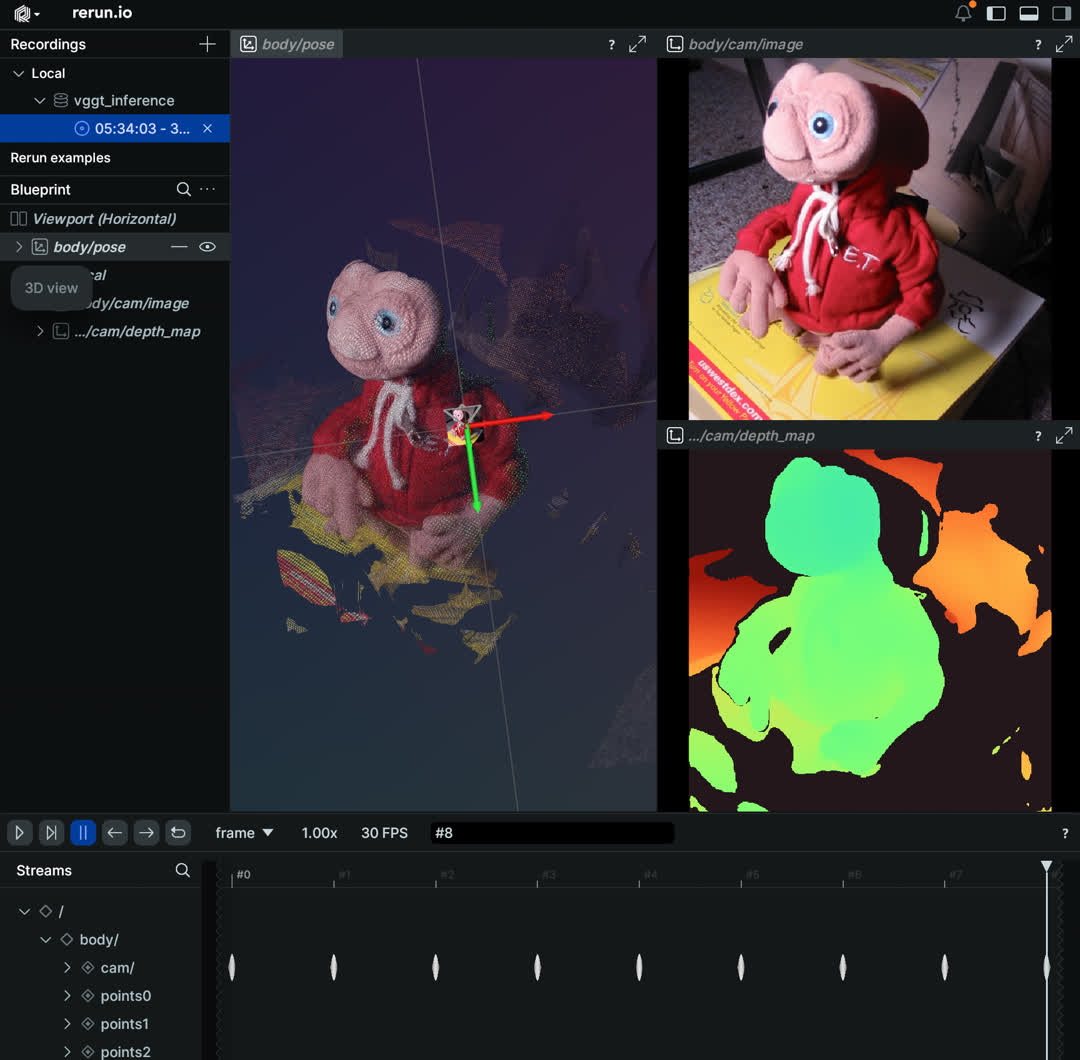